# Working code for the biomechzoo Ensembler
This is the plotting library associated with the biomechzoo toolbox. This means that the data inputted into these plotting functions need to be _zoo files_ or structured as nested dictionaries.

In [2]:
# import statements
from src.ensembler import Ensembler
from src.plot_spec import PlotSpec
from src.renderers import IndividualLinesRenderer, MeanSDRenderer, CompositeRenderer, ViolinRenderer, EventOverlayRenderer
from src.helpers import ConditionSpec, ConditionSource

## Variables
The following variables should be set a priori for it to work
1. **in_folder**: path to the root where the data is stored
2. **conditions**: Optional if there are multiple conditions.
3. **channels**: the channel names that you'd want to plot
4. **str_match**: list of regular expression that matches the subject names. if emtpy; provide a subject list
5. **subj_list**: list of strings containing the subject names. if empty; provide a str_match.
6. **rows**: number of subplot rows
7. **cols**: number of subplot cols.


`condition_spec = ConditionSpec(source = ConditionSource.FOLDER, conditions=["Pre-surgery", "Post-surgery"])`


In [3]:
# Set up variables.
fld = "/Users/Werk/Documents/Postdoc-McGill/areve-mcgill/data/Round2/16-qc"

spec = ConditionSpec(
    source     = ConditionSource.CHANNEL,
    conditions = ["vicon", "areve", 'pig'],
    channel_map = {
        "vicon": "RS_abduction_vicon",
        "areve": "RS_abduction_areve",
        "pig" : "RS_abduction_pig",
    }
)
channels = ['RS_abduction']
str_match = [r"\b\d{3}[A-Z]{2}\b", r"\b\d{3}[A-Z]{3}\b"]
# subj_list = ["001CEJ"]
events = ["max"]
rows = 1
cols = 3


## Using the ensembler
This is a collection of classes that work together to obtain clean and consistent plotting.
Currently implemented figures are:
1. Individual line plots (`IndividualLinesRendered()`)
2. Average +/- standard deviation of curves (`MeanSDRenderer()`)

`CompositeRendered()` allows the uses to combine different renderers into a single subplot without needing extra lines of code.
All renders are called in the `add_subplot` method from the Ensembler class alongside the channel name, row/col combination in which subplot to put it.

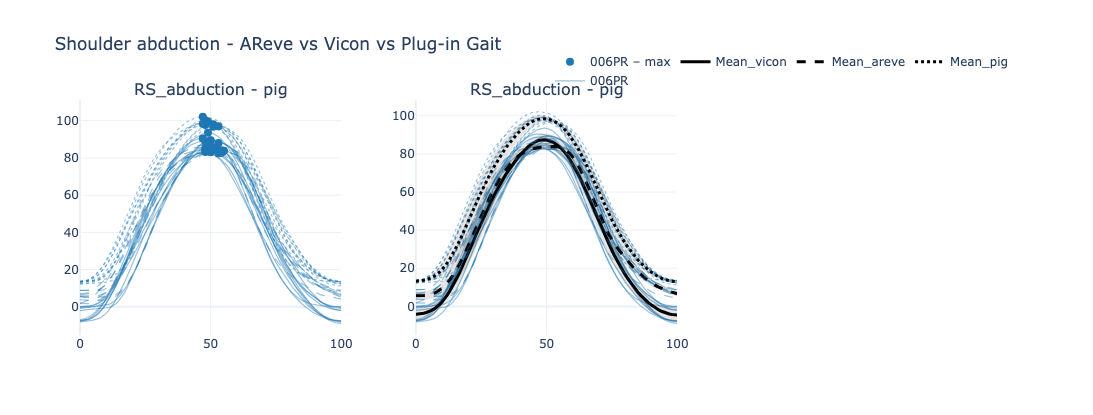

In [7]:
lines_and_mean = CompositeRenderer(IndividualLinesRenderer(), MeanSDRenderer())
lines_and_events = CompositeRenderer(IndividualLinesRenderer(), EventOverlayRenderer())

fig = (
    Ensembler(in_folder=fld, channels=channels, n_rows = rows,  n_cols =cols, str_match=str_match, condition_spec=spec)
    .add_subplot(PlotSpec('RS_abduction', "vicon", row=1, col=1, renderer=lines_and_events, events=events))
    .add_subplot(PlotSpec('RS_abduction', "areve", row=1, col=1, renderer=lines_and_events, events=events))
    .add_subplot(PlotSpec('RS_abduction', "pig", row=1, col=1, renderer=lines_and_events,events=events))
        
    .add_subplot(PlotSpec('RS_abduction', "vicon", row=1, col=2, renderer=lines_and_mean, events=events))
    .add_subplot(PlotSpec('RS_abduction', "areve", row=1, col=2, renderer=lines_and_mean, events=events))
    .add_subplot(PlotSpec('RS_abduction', "pig", row=1, col=2, renderer=lines_and_mean,events=events))
    
        .build(title="Shoulder abduction - AReve vs Vicon vs Plug-in Gait")
)
fig.show()

## Extras
The returned fig from the ensembler allows the user all the functionality of plotly figures.
e.g. add annotations to the plot

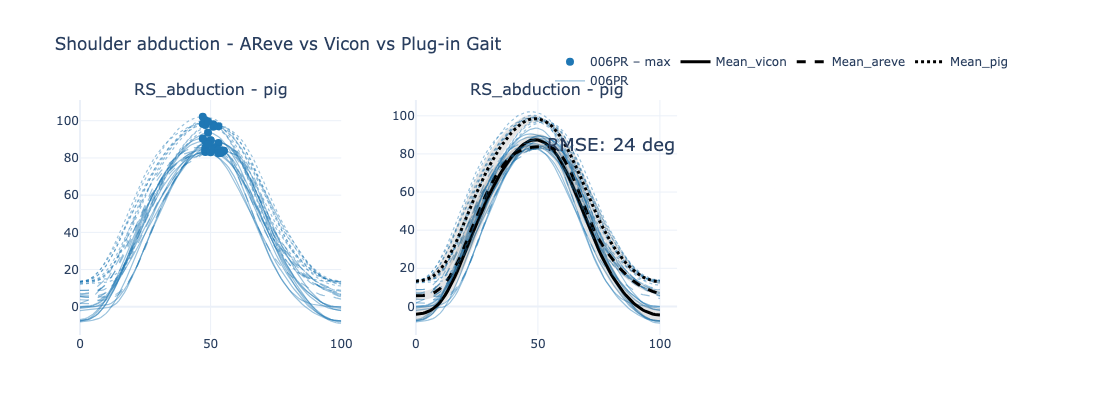

In [8]:
fig.add_annotation(x=80, y=80, showarrow=False,
            text="RMSE: 24 deg",
            yshift=10, font=dict(size=18), row=1,col=2)

# Our first statistical plot

In [17]:
# Set up variables
fld = "/Users/Werk/Documents/Postdoc-McGill/breast-reduction/data/stats"
spec = ConditionSpec(
    source = ConditionSource.FOLDER,
    conditions = ["Pre-surgery", "Post-Surgery"]
)

channels = ['ax_pelvis_tilt_corr']
str_match = [r"\b\d{3}[A-Z]{2}\b", r"\b\d{3}[A-Z]{3}\b"]
# subj_list = ["001CEJ"]
events = ['impact_peak_mean', 'loading_rate_mean']
rows = 1
cols = 3

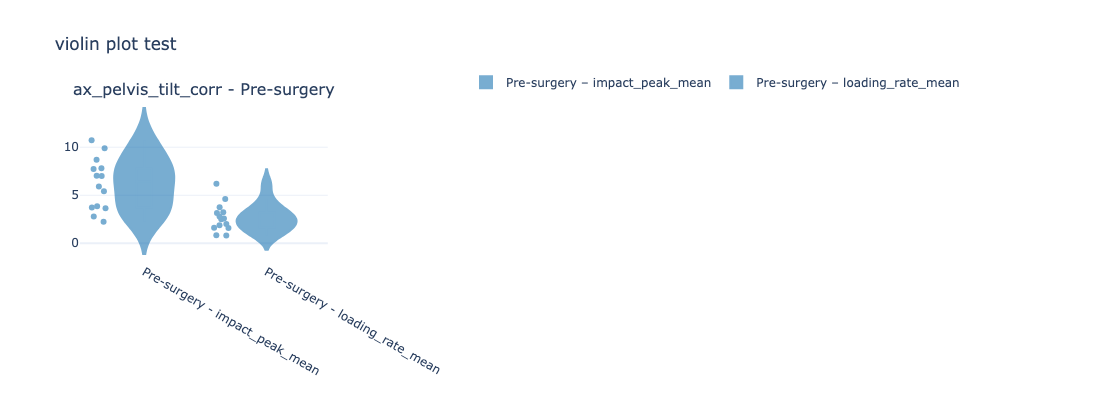

In [18]:
fig = (
    Ensembler(in_folder=fld, channels=channels, n_rows = rows,  n_cols =cols, str_match=str_match, condition_spec=spec, events=events)
    .add_subplot(PlotSpec(
        channel="ax_pelvis_tilt_corr",
        condition = "Pre-surgery",
        companions = ["Post-surgery"],
        row=1, col=1,
        renderer=ViolinRenderer(),
        events=events))
    .build(title="violin plot test")
)
fig.show()

## Individual lines with marker overlay
Example on a single participant

In [ ]:
# # Set up variables.
# fld = "/Users/Werk/Documents/Postdoc-McGill/areve-mcgill/data/15-qc"
#
# channels = ['shoulder_abduction_angle_vicon-offset', 'shoulder_abduction_angle-offset',]
# str_match = [r"\b\d{3}[A-Z]{2}\b", r"\b\d{3}[A-Z]{3}\b"]
# # subj_list = ["001CEJ"]
# events = ["max"]
# rows = 1
# cols = 1

In [ ]:
# lines_with_events = CompositeRenderer(IndividualLinesRenderer(), EventOverlayRenderer())
# fig = (Ensembler(in_folder=fld, channels=channels, n_rows=1, n_cols=2, str_match=str_match, events=events)
#        .add_subplot(PlotSpec(channels[0], row=1, col=1, renderer=lines_with_events, events=events))
#        .add_subplot(PlotSpec(channels[0], row=1, col=2, renderer=ViolinRenderer(), events=events))
#        .build(title="Shoulder abduction - with events overlay single participant")
#        )
# fig.show()
